# 090 — Finite-distance array analysis

Replace the plane-wave approximation with exact source-to-sensor distances.
The primary analyses are (1) a fixed-source SLC-40 speed search and (2) a
source-oriented range/cross-range profile that exposes the weak along-range
constraint of this small, distant array. Notebook 080 remains the catalogue and
quality-control authority; this notebook is a finite-distance sensitivity test,
not an independent event selector or a uniquely constrained source locator.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
from pyproj import Transformer, Geod
from obspy import read

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from modules import project_config as config

PLANAR_ROOT = config.NB080_DIR
PREPARATION_ROOT = config.NB070_DIR
ANALYSIS_CONFIG_FILE = config.NB010_DIR / "analysis_configuration.json"

OUTPUT_ROOT = config.NB090_DIR
FIGURE_DIR = OUTPUT_ROOT / "event_figures"
SURFACE_DIR = OUTPUT_ROOT / "surfaces"
COMPOSITE_DIR = OUTPUT_ROOT / "composites"

for directory in (
    OUTPUT_ROOT,
    FIGURE_DIR,
    SURFACE_DIR,
    COMPOSITE_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

PLANAR_RESULTS_FILE = PLANAR_ROOT / "planar_array_results.csv"
EVENT_FILTER_FILE = PLANAR_ROOT / "event_filter_decisions.csv"
EVENT_STREAM_DIR = PREPARATION_ROOT / "event_streams"

CHANNELS = ("DD1", "DD2", "DD3")
REFERENCE_CHANNEL = "DD2"
PRINCIPAL_EXPLOSION_EVENT_NUMBER = 13
EXPECTED_EVENT_COUNT = 153

SCORE_WEIGHT_SEMBLANCE = 0.60

# Fixed-source speed search.
SPEED_MIN_MPS = 280.0
SPEED_MAX_MPS = 440.0
SPEED_STEP_MPS = 0.5

# Constrained local source search. This speed is not optimized simultaneously.
LOCAL_GRID_SPEED_MPS = 352.0
LOCAL_COARSE_HALF_WIDTH_M = 100.0
LOCAL_COARSE_STEP_M = 5.0
LOCAL_FINE_HALF_WIDTH_M = 12.0
LOCAL_FINE_STEP_M = 1.0

# Descriptive near-maximum widths, not formal confidence regions.
SURFACE_SCORE_DROPS = (0.01, 0.02)

RUN_LOCAL_SOURCE_GRID = False  # Legacy Cartesian point-location experiment; retained but disabled.
MAKE_EVENT_FIGURES = False     # Superseded by range-profile figures below.
SAVE_EVENT_SURFACES = True
MAX_EVENTS: int | None = None

# Preferred constraint analysis in source-oriented coordinates. Along-range is
# intentionally much broader than cross-range so an open range ridge is visible.
RUN_RANGE_PROFILE_ANALYSIS = True
ALONG_RANGE_HALF_WIDTH_M = 500.0
ALONG_RANGE_STEP_M = 20.0
CROSS_RANGE_HALF_WIDTH_M = 150.0
CROSS_RANGE_STEP_M = 5.0
MAKE_PROFILE_EVENT_FIGURES = True
PROFILE_FIGURE_QUALITY_CLASSES = ("A_high_quality",)
PROFILE_FIGURE_EVENT_NUMBERS = (PRINCIPAL_EXPLOSION_EVENT_NUMBER,)

# Optional explicit source coordinate. When None, reconstruct SLC-40 from the
# canonical source latitude/longitude in the analysis configuration.
SLC40_EAST_M_OVERRIDE: float | None = None
SLC40_NORTH_M_OVERRIDE: float | None = None
SOURCE_ELEVATION_M = 0.0

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 240,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Load the planar catalogue and reconstructed geometry

Notebook 080 remains the event-selection and quality-class authority. This notebook
requires its complete 153-event result, preserves event numbering and scoring
windows, and carries its continuous quality/stability metrics forward. Thus any
coherence change arises from the propagation model rather than a changed catalogue.

The nominal SLC-40 coordinate is taken from the shared configuration. Reported and
coordinate-derived source-to-sensor distances are compared as a geometry audit.
Back azimuth below is centroid referenced and measured from projected grid
north. The configuration reference is the BCHH seismometer and its geodesic
back azimuth uses geographic north. The audit separates these conventions;
their difference must not be attributed solely to source motion or sensor error.


In [2]:
if not ANALYSIS_CONFIG_FILE.exists():
    raise FileNotFoundError(ANALYSIS_CONFIG_FILE)

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())

if analysis_config["infrasound_reference_channel"] != REFERENCE_CHANNEL:
    raise ValueError("Finite-distance implementation requires configured DD2 reference")

GEOMETRY_FILE = Path(
    analysis_config["geometry_file"]
).expanduser()

for required in (PLANAR_RESULTS_FILE, GEOMETRY_FILE):
    if not required.exists():
        raise FileNotFoundError(required)

planar = (
    pd.read_csv(PLANAR_RESULTS_FILE)
    .sort_values("event_number")
    .reset_index(drop=True)
)
required_planar_columns = {
    "event_number", "stream_file", "reference_time_epoch_s",
    "score_window_start_s", "score_window_end_s",
    "best_back_azimuth_deg", "best_apparent_speed_mps",
    "maximum_coherence_score", "solution_quality_class",
}
missing_planar_columns = sorted(required_planar_columns - set(planar.columns))
if missing_planar_columns:
    raise ValueError(
        "Notebook 080 output is stale or incompatible; missing columns: "
        + ", ".join(missing_planar_columns)
    )

if MAX_EVENTS is None:
    expected_numbers = np.arange(1, EXPECTED_EVENT_COUNT + 1)
    actual_numbers = planar["event_number"].to_numpy(int)
    if len(planar) != EXPECTED_EVENT_COUNT or not np.array_equal(actual_numbers, expected_numbers):
        raise ValueError(
            f"Expected the complete Notebook 080 catalogue numbered 1–{EXPECTED_EVENT_COUNT}; "
            f"found {len(planar)} rows spanning "
            f"{actual_numbers.min() if len(actual_numbers) else 'NA'}–"
            f"{actual_numbers.max() if len(actual_numbers) else 'NA'}. "
            "Re-run the revised Notebook 080 before Notebook 090."
        )
else:
    planar = planar.head(MAX_EVENTS).copy()
    print(f"DEVELOPMENT MODE: limiting analysis to {len(planar)} events")

duplicate_events = planar.loc[planar["event_number"].duplicated(), "event_number"].tolist()
if duplicate_events:
    raise ValueError(f"Duplicate Notebook 080 event numbers: {duplicate_events}")

resolved_stream_files = []
missing_stream_files = []
for row in planar.itertuples(index=False):
    stream_path = Path(row.stream_file)
    if not stream_path.exists():
        stream_path = EVENT_STREAM_DIR / f"candidate_event_{int(row.event_number):03d}.pkl"
    resolved_stream_files.append(str(stream_path))
    if not stream_path.exists():
        missing_stream_files.append((int(row.event_number), str(stream_path)))
if missing_stream_files:
    preview = "; ".join(f"event {event}: {path}" for event, path in missing_stream_files[:8])
    raise FileNotFoundError(
        f"Missing {len(missing_stream_files)} event streams required by Notebook 090. "
        f"First missing files: {preview}"
    )
planar["resolved_stream_file"] = resolved_stream_files

geometry = pd.read_csv(GEOMETRY_FILE)
geometry["channel"] = geometry["channel"].astype(str).str.upper()

if geometry["channel"].duplicated().any():
    raise ValueError("Duplicate geometry channel rows")

sensor_geometry = (
    geometry.loc[geometry["channel"].isin(CHANNELS)]
    .copy()
    .set_index("channel")
    .loc[list(CHANNELS)]
)

east_column = next(
    c for c in ("easting_m", "easting", "x_m")
    if c in sensor_geometry.columns
)
north_column = next(
    c for c in ("northing_m", "northing", "y_m")
    if c in sensor_geometry.columns
)
elevation_column = next(
    (
        c
        for c in ("elevation_m", "elevation", "z_m")
        if c in sensor_geometry.columns
    ),
    None,
)

sensor_xyz = np.column_stack([
    sensor_geometry[east_column].to_numpy(float),
    sensor_geometry[north_column].to_numpy(float),
    (
        sensor_geometry[elevation_column].to_numpy(float)
        if elevation_column
        else np.zeros(len(CHANNELS))
    ),
])

slc40_config = analysis_config["slc40"]

if (SLC40_EAST_M_OVERRIDE is None) != (SLC40_NORTH_M_OVERRIDE is None):
    raise ValueError("Provide both projected source coordinates or neither")
if not np.isfinite(sensor_xyz).all():
    raise ValueError("Nonfinite sensor coordinates")

if SLC40_EAST_M_OVERRIDE is not None and SLC40_NORTH_M_OVERRIDE is not None:
    slc40_xy = np.array(
        [SLC40_EAST_M_OVERRIDE, SLC40_NORTH_M_OVERRIDE],
        dtype=float,
    )
    source_coordinate_method = "explicit projected override"
else:
    transformer = Transformer.from_crs(
        "EPSG:4326",
        "EPSG:32617",
        always_xy=True,
    )
    source_east_m, source_north_m = transformer.transform(
        float(slc40_config["longitude"]),
        float(slc40_config["latitude"]),
    )
    slc40_xy = np.array(
        [source_east_m, source_north_m],
        dtype=float,
    )
    source_coordinate_method = "canonical SLC-40 latitude/longitude"

slc40_xyz = np.array(
    [slc40_xy[0], slc40_xy[1], SOURCE_ELEVATION_M],
    dtype=float,
)

reported_distances_m = (
    sensor_geometry["distance_m"].to_numpy(float)
    if "distance_m" in sensor_geometry.columns
    else np.full(len(CHANNELS), np.nan)
)
canonical_distances_m = np.linalg.norm(
    sensor_xyz - slc40_xyz,
    axis=1,
)
source_fit_residuals_m = (
    canonical_distances_m - reported_distances_m
)

array_centroid_xyz = sensor_xyz.mean(axis=0)
source_vector = slc40_xyz[:2] - array_centroid_xyz[:2]
slc40_range_m = float(np.linalg.norm(source_vector))
slc40_back_azimuth_deg = float(
    np.degrees(
        np.arctan2(source_vector[0], source_vector[1])
    )
    % 360.0
)

geometry_audit = pd.DataFrame({
    "channel": CHANNELS,
    "east_m": sensor_xyz[:, 0],
    "north_m": sensor_xyz[:, 1],
    "elevation_m": sensor_xyz[:, 2],
    "reported_distance_m": sensor_geometry.get(
        "distance_m",
        pd.Series(np.nan, index=sensor_geometry.index),
    ).to_numpy(float),
    "fitted_distance_m": np.linalg.norm(
        sensor_xyz - slc40_xyz,
        axis=1,
    ),
    "distance_fit_residual_m": source_fit_residuals_m,
})
geometry_audit.to_csv(
    OUTPUT_ROOT / "circular_geometry_audit.csv",
    index=False,
)

print(f"Planar results: {PLANAR_RESULTS_FILE}")
print(f"Geometry: {GEOMETRY_FILE}")
print(f"Validated events inherited from Notebook 080: {len(planar)}")
print("Notebook 080 quality classes:")
display(planar["solution_quality_class"].value_counts().rename("events").to_frame())
print(
    f"SLC-40 ({source_coordinate_method}): "
    f"E={slc40_xyz[0]:.3f} m, "
    f"N={slc40_xyz[1]:.3f} m"
)
print(
    f"Centroid-to-source range={slc40_range_m:.2f} m; "
    f"back azimuth={slc40_back_azimuth_deg:.3f}°"
)
display(geometry_audit)


Planar results: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/080_analyze_planar_array_propagation/planar_array_results.csv
Geometry: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/010_prepare_analysis_inputs/bchh_channels.csv
Validated events inherited from Notebook 080: 153
Notebook 080 quality classes:


,events
solution_quality_class,
C_weak_or_broad,57
A_high_quality,51
B_probable,45


SLC-40 (canonical SLC-40 latitude/longitude): E=541352.817 m, N=3159526.382 m
Centroid-to-source range=1419.79 m; back azimuth=199.025°


,channel,east_m,north_m,elevation_m,reported_distance_m,fitted_distance_m,distance_fit_residual_m
0,DD1,541816.300901,3.160889e+06,0.0,1439.963831,1439.418575,-0.545255
1,DD2,541828.276924,3.160851e+06,0.0,1408.338457,1407.805185,-0.533272
2,DD3,541802.343163,3.160865e+06,0.0,1412.854330,1412.319330,-0.535000


## Coherence and exact-distance helpers

For a trial source position \(\mathbf{x}_s\) and speed \(c\), the receiver delay
relative to DD2 is

\[
\Delta t_i=\frac{\lVert\mathbf{x}_i-\mathbf{x}_s\rVert-
\lVert\mathbf{x}_{DD2}-\mathbf{x}_s\rVert}{c}.
\]

The same normalized three-channel coherence statistic and event scoring windows
used in Notebook 080 are retained.


In [3]:
def unique_trace(stream, channel):
    matches = stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(f"Expected one {channel}; found {len(matches)}")
    return matches[0]


def interpolate_trace_epoch(trace, epoch_s):
    start = float(trace.stats.starttime.timestamp)
    rate = float(trace.stats.sampling_rate)
    source_epoch = start + np.arange(trace.stats.npts, dtype=float) / rate
    return np.interp(epoch_s, source_epoch, np.asarray(trace.data, float), left=np.nan, right=np.nan)


def delays_for_source(source_xyz, speed_mps):
    distances = np.linalg.norm(sensor_xyz - np.asarray(source_xyz, float), axis=1)
    reference_index = CHANNELS.index(REFERENCE_CHANNEL)
    return {channel: float((distances[i] - distances[reference_index]) / speed_mps)
            for i, channel in enumerate(CHANNELS)}


def aligned_waveforms(stream, reference_epoch_s, relative_delays_s, window_relative_s):
    rates = [float(unique_trace(stream, channel).stats.sampling_rate) for channel in CHANNELS]
    if not np.allclose(rates, rates[0]):
        raise ValueError(f"Sampling rates differ: {rates}")
    dt = 1.0 / rates[0]
    relative_time = np.arange(window_relative_s[0], window_relative_s[1] + 0.5 * dt, dt)
    rows = []
    for channel in CHANNELS:
        trace = unique_trace(stream, channel)
        sample_epoch = reference_epoch_s + relative_time + relative_delays_s[channel]
        rows.append(interpolate_trace_epoch(trace, sample_epoch))
    values = np.vstack(rows)
    if not np.isfinite(values).all():
        raise ValueError("Trial delay exceeds inherited scoring-window coverage; regenerate wider 070 segments")
    return relative_time, values


def coherence_metrics(aligned):
    aligned = np.asarray(aligned, float)
    finite = np.all(np.isfinite(aligned), axis=0)
    aligned = aligned[:, finite]
    if aligned.shape[1] < 5:
        return dict(semblance=np.nan, mean_pairwise_correlation=np.nan, coherence_score=np.nan)
    centered = aligned - np.nanmedian(aligned, axis=1, keepdims=True)
    rms = np.sqrt(np.nanmean(centered ** 2, axis=1, keepdims=True))
    if np.any(~np.isfinite(rms)) or np.any(rms <= 0):
        return dict(semblance=np.nan, mean_pairwise_correlation=np.nan, coherence_score=np.nan)
    normalized = centered / rms
    numerator = np.sum(np.sum(normalized, axis=0) ** 2)
    denominator = len(CHANNELS) * np.sum(normalized ** 2)
    semblance = float(numerator / denominator)
    correlations = [
        np.corrcoef(normalized[i], normalized[j])[0, 1]
        for i in range(len(CHANNELS)) for j in range(i + 1, len(CHANNELS))
    ]
    mean_corr = float(np.mean(correlations))
    corr_01 = np.clip((mean_corr + 1.0) / 2.0, 0.0, 1.0)
    score = SCORE_WEIGHT_SEMBLANCE * semblance + (1.0 - SCORE_WEIGHT_SEMBLANCE) * corr_01
    return dict(semblance=semblance, mean_pairwise_correlation=mean_corr, coherence_score=float(score))


def score_model(stream, reference_epoch_s, score_window_s, delays):
    _, aligned = aligned_waveforms(stream, reference_epoch_s, delays, score_window_s)
    return coherence_metrics(aligned)


def search_speed_fixed_source(stream, reference_epoch_s, score_window_s, source_xyz, speed_grid):
    rows = []
    for speed in speed_grid:
        metrics = score_model(stream, reference_epoch_s, score_window_s, delays_for_source(source_xyz, speed))
        rows.append((metrics["coherence_score"], metrics["semblance"], metrics["mean_pairwise_correlation"]))
    surface = np.asarray(rows, float)
    if not np.isfinite(surface[:, 0]).any():
        raise ValueError("Fixed-source speed surface is entirely nonfinite")
    best = int(np.nanargmax(surface[:, 0]))
    return best, surface


def search_source_grid(stream, reference_epoch_s, score_window_s, east_grid, north_grid, speed_mps):
    score = np.full((len(north_grid), len(east_grid)), np.nan)
    semblance = np.full_like(score, np.nan)
    correlation = np.full_like(score, np.nan)
    for iy, north in enumerate(north_grid):
        for ix, east in enumerate(east_grid):
            source = np.array([east, north, SOURCE_ELEVATION_M])
            metrics = score_model(stream, reference_epoch_s, score_window_s, delays_for_source(source, speed_mps))
            score[iy, ix] = metrics["coherence_score"]
            semblance[iy, ix] = metrics["semblance"]
            correlation[iy, ix] = metrics["mean_pairwise_correlation"]
    best_flat = int(np.nanargmax(score))
    best_iy, best_ix = np.unravel_index(best_flat, score.shape)
    return best_ix, best_iy, score, semblance, correlation


def surface_widths(east_grid, north_grid, score, maximum, drops=SURFACE_SCORE_DROPS):
    output = {}
    for drop in drops:
        mask = score >= maximum - drop
        label = str(drop).replace(".", "p")
        if np.any(mask):
            yy, xx = np.where(mask)
            output[f"east_width_drop_{label}_m"] = float(east_grid[xx].max() - east_grid[xx].min())
            output[f"north_width_drop_{label}_m"] = float(north_grid[yy].max() - north_grid[yy].min())
            output[f"area_drop_{label}_m2"] = float(mask.sum() * np.median(np.diff(east_grid)) * np.median(np.diff(north_grid)))
        else:
            output[f"east_width_drop_{label}_m"] = np.nan
            output[f"north_width_drop_{label}_m"] = np.nan
            output[f"area_drop_{label}_m2"] = np.nan
    return output


def source_offsets(source_xyz):
    delta = np.asarray(source_xyz[:2]) - slc40_xyz[:2]
    radial_unit = source_vector / np.linalg.norm(source_vector)
    cross_unit = np.array([radial_unit[1], -radial_unit[0]])
    return float(delta @ radial_unit), float(delta @ cross_unit)

# Separate source-bearing conventions from finite-wavefront curvature.
inverse_projection = Transformer.from_crs("EPSG:32617", "EPSG:4326", always_xy=True)
source_lon, source_lat = inverse_projection.transform(slc40_xyz[0], slc40_xyz[1])
centroid_lon, centroid_lat = inverse_projection.transform(array_centroid_xyz[0], array_centroid_xyz[1])
geodesic = Geod(ellps="WGS84")
centroid_geographic_baz = geodesic.inv(centroid_lon, centroid_lat, source_lon, source_lat)[0] % 360
reference_baz = float(analysis_config["array_reference"]["back_azimuth_to_slc40_deg"])
(OUTPUT_ROOT / "direction_reference_audit.json").write_text(json.dumps({
    "centroid_grid_baz_deg": slc40_back_azimuth_deg,
    "centroid_geographic_baz_deg": centroid_geographic_baz,
    "configured_reference_name": analysis_config["array_reference"]["name"],
    "configured_reference_geographic_baz_deg": reference_baz,
    "geographic_minus_grid_centroid_deg": (centroid_geographic_baz - slc40_back_azimuth_deg + 180) % 360 - 180,
    "scope": "Bearing convention audit; nominal inversions unchanged"
}, indent=2) + "\n")
# Plane wave points in the same centroid-to-source direction as exact model.
propagation_unit = (array_centroid_xyz[:2] - slc40_xyz[:2]) / slc40_range_m
projected_paths = (sensor_xyz[:, :2] - sensor_xyz[CHANNELS.index(REFERENCE_CHANNEL), :2]) @ propagation_unit
curvature_rows = []
for speed in (351.0, LOCAL_GRID_SPEED_MPS):
    exact = delays_for_source(slc40_xyz, speed)
    for i, channel in enumerate(CHANNELS):
        curvature_rows.append({"channel": channel, "speed_mps": speed,
            "matched_direction_planar_delay_s": projected_paths[i]/speed,
            "exact_relative_delay_s": exact[channel],
            "curvature_delay_difference_s": exact[channel] - projected_paths[i]/speed})
curvature_audit = pd.DataFrame(curvature_rows)
curvature_audit.to_csv(OUTPUT_ROOT / "matched_direction_curvature_audit.csv", index=False)
display(curvature_audit)


,channel,speed_mps,matched_direction_planar_delay_s,exact_relative_delay_s,curvature_delay_difference_s
0,DD1,351.0,0.090341,0.090067,-0.000275
1,DD2,351.0,0.000000,0.000000,0.000000
2,DD3,351.0,0.013039,0.012861,-0.000178
3,DD1,352.0,0.090085,0.089811,-0.000274
4,DD2,352.0,0.000000,0.000000,0.000000
5,DD3,352.0,0.013002,0.012824,-0.000178


## Fixed SLC-40 source: search acoustic speed

For each event, the source is fixed at SLC-40 and acoustic speed is searched using
exact Euclidean source-to-sensor path-length differences. Sensor elevations are
used when available, but source elevation is assumed to be 0 m; this is therefore
primarily a horizontal finite-distance (circular-wavefront) test rather than a
fully constrained 3-D source model.

Because fixing SLC-40 also fixes direction, speed can compensate for a small
directional mismatch. The resulting speed is consequently a model-sensitivity
diagnostic and does not supersede the planar/Notebook-040 propagation estimate.


In [4]:
speed_grid = np.arange(SPEED_MIN_MPS, SPEED_MAX_MPS + 0.25 * SPEED_STEP_MPS, SPEED_STEP_MPS)
fixed_rows = []
event_cache = {}

for count, row in enumerate(planar.itertuples(index=False), start=1):
    stream_path = Path(row.resolved_stream_file)
    stream = read(str(stream_path), format="PICKLE")
    reference_epoch_s = float(row.reference_time_epoch_s)
    score_window = (float(row.score_window_start_s), float(row.score_window_end_s))
    best, surface = search_speed_fixed_source(stream, reference_epoch_s, score_window, slc40_xyz, speed_grid)
    best_speed = float(speed_grid[best])
    best_score, best_semblance, best_corr = surface[best]
    delays = delays_for_source(slc40_xyz, best_speed)
    fixed_rows.append({
        "event_number": int(row.event_number),
        "reference_time_epoch_s": reference_epoch_s,
        "reference_time_utc": pd.to_datetime(reference_epoch_s, unit="s", utc=True),
        "passes_core_filter": bool(getattr(row, "passes_core_filter", False)),
        "solution_quality_class": str(row.solution_quality_class),
        "stability_back_azimuth_std_deg": float(getattr(row, "stability_back_azimuth_std_deg", np.nan)),
        "stability_speed_std_mps": float(getattr(row, "stability_speed_std_mps", np.nan)),
        "stability_score_min": float(getattr(row, "stability_score_min", np.nan)),
        "stability_valid_window_count": int(getattr(row, "stability_valid_window_count", 0)),
        "planar_back_azimuth_deg": float(row.best_back_azimuth_deg),
        "planar_speed_mps": float(row.best_apparent_speed_mps),
        "planar_coherence_score": float(row.maximum_coherence_score),
        "fixed_source_speed_mps": best_speed,
        "fixed_source_coherence_score": float(best_score),
        "fixed_source_semblance": float(best_semblance),
        "fixed_source_mean_pairwise_correlation": float(best_corr),
        "fixed_minus_planar_coherence": float(best_score - row.maximum_coherence_score),
        "fixed_dd1_delay_relative_dd2_s": delays["DD1"],
        "fixed_dd3_delay_relative_dd2_s": delays["DD3"],
        "fixed_speed_on_search_edge": bool(best in (0, len(speed_grid) - 1)),
        "score_window_start_s": score_window[0],
        "score_window_end_s": score_window[1],
        "stream_file": str(stream_path),
    })
    event_cache[int(row.event_number)] = dict(stream=stream, reference_epoch_s=reference_epoch_s, score_window=score_window, speed_surface=surface)
    if SAVE_EVENT_SURFACES:
        np.savez_compressed(SURFACE_DIR / f"event_{int(row.event_number):03d}_fixed_source_speed.npz",
                            speed_mps=speed_grid, coherence_score=surface[:, 0],
                            semblance=surface[:, 1], mean_pairwise_correlation=surface[:, 2])
    print(f"[{count:03d}/{len(planar):03d}] event {int(row.event_number):03d}: "
          f"fixed-source speed={best_speed:.1f} m/s, score={best_score:.3f}, "
          f"Δscore={best_score-row.maximum_coherence_score:+.3f}")

fixed_results = pd.DataFrame(fixed_rows)
fixed_results.to_csv(OUTPUT_ROOT / "fixed_slc40_spherical_results.csv", index=False)
display(fixed_results.head())


[001/153] event 001: fixed-source speed=358.5 m/s, score=0.952, Δscore=-0.028
[002/153] event 002: fixed-source speed=359.0 m/s, score=0.953, Δscore=-0.008
[003/153] event 003: fixed-source speed=358.0 m/s, score=0.948, Δscore=-0.009
[004/153] event 004: fixed-source speed=347.5 m/s, score=0.863, Δscore=-0.010
[005/153] event 005: fixed-source speed=365.5 m/s, score=0.796, Δscore=-0.011
[006/153] event 006: fixed-source speed=345.0 m/s, score=0.928, Δscore=-0.007
[007/153] event 007: fixed-source speed=355.5 m/s, score=0.794, Δscore=-0.022
[008/153] event 008: fixed-source speed=363.0 m/s, score=0.940, Δscore=-0.015
[009/153] event 009: fixed-source speed=352.0 m/s, score=0.978, Δscore=-0.010
[010/153] event 010: fixed-source speed=350.5 m/s, score=0.944, Δscore=-0.011
[011/153] event 011: fixed-source speed=353.0 m/s, score=0.972, Δscore=-0.003
[012/153] event 012: fixed-source speed=355.0 m/s, score=0.989, Δscore=-0.008
[013/153] event 013: fixed-source speed=354.5 m/s, score=0.997, 

,event_number,reference_time_epoch_s,reference_time_utc,passes_core_filter,solution_quality_class,stability_back_azimuth_std_deg,stability_speed_std_mps,stability_score_min,stability_valid_window_count,planar_back_azimuth_deg,...,fixed_source_coherence_score,fixed_source_semblance,fixed_source_mean_pairwise_correlation,fixed_minus_planar_coherence,fixed_dd1_delay_relative_dd2_s,fixed_dd3_delay_relative_dd2_s,fixed_speed_on_search_edge,score_window_start_s,score_window_end_s,stream_file
0,1,1.472735e+09,2016-09-01 13:07:15.927133560+00:00,True,A_high_quality,0.291018,0.724356,0.968607,9,200.9,...,0.952375,0.947204,0.920263,-0.027607,0.088182,0.012592,False,-0.04,0.18,/Users/thompsong/Developer/KSCRocketSeismology...
1,2,1.472735e+09,2016-09-01 13:07:16.057133436+00:00,True,A_high_quality,0.226623,2.403701,0.958165,9,201.6,...,0.953251,0.948437,0.920944,-0.007859,0.088060,0.012574,False,-0.04,0.18,/Users/thompsong/Developer/KSCRocketSeismology...
2,3,1.472735e+09,2016-09-01 13:07:16.255000114+00:00,True,A_high_quality,0.177082,1.509231,0.949664,9,201.3,...,0.947775,0.943281,0.909030,-0.009461,0.088306,0.012609,False,-0.04,0.18,/Users/thompsong/Developer/KSCRocketSeismology...
3,4,1.472735e+09,2016-09-01 13:07:16.447066784+00:00,False,B_probable,0.397523,1.683251,0.856808,9,200.8,...,0.862718,0.849685,0.764536,-0.010190,0.090974,0.012990,False,-0.04,0.18,/Users/thompsong/Developer/KSCRocketSeismology...
4,5,1.472735e+09,2016-09-01 13:07:16.799566746+00:00,False,B_probable,0.244949,4.186250,0.788955,9,200.7,...,0.796014,0.773105,0.660753,-0.010511,0.086494,0.012351,False,-0.04,0.18,/Users/thompsong/Developer/KSCRocketSeismology...


## Disabled legacy Cartesian source grid

The older fixed-speed Cartesian point search is retained for reproducibility but
disabled. With only three closely spaced sensors, source east, source north, and
speed are not jointly identifiable from relative delays. A point maximum—especially
one on a grid edge—must not be interpreted as an independently located source.


In [5]:
local_rows = []
coarse_composite_surfaces = []
coarse_east_offsets = np.arange(-LOCAL_COARSE_HALF_WIDTH_M, LOCAL_COARSE_HALF_WIDTH_M + 0.25 * LOCAL_COARSE_STEP_M, LOCAL_COARSE_STEP_M)
coarse_north_offsets = np.arange(-LOCAL_COARSE_HALF_WIDTH_M, LOCAL_COARSE_HALF_WIDTH_M + 0.25 * LOCAL_COARSE_STEP_M, LOCAL_COARSE_STEP_M)
coarse_east = slc40_xyz[0] + coarse_east_offsets
coarse_north = slc40_xyz[1] + coarse_north_offsets

if RUN_LOCAL_SOURCE_GRID:
    for count, fixed in enumerate(fixed_results.itertuples(index=False), start=1):
        cached = event_cache[int(fixed.event_number)]
        stream = cached["stream"]
        reference_epoch_s = cached["reference_epoch_s"]
        score_window = cached["score_window"]
        bx, by, coarse_score, coarse_sem, coarse_corr = search_source_grid(
            stream, reference_epoch_s, score_window, coarse_east, coarse_north, LOCAL_GRID_SPEED_MPS
        )
        coarse_best_east = coarse_east[bx]
        coarse_best_north = coarse_north[by]
        fine_east = np.arange(coarse_best_east - LOCAL_FINE_HALF_WIDTH_M,
                              coarse_best_east + LOCAL_FINE_HALF_WIDTH_M + 0.25 * LOCAL_FINE_STEP_M,
                              LOCAL_FINE_STEP_M)
        fine_north = np.arange(coarse_best_north - LOCAL_FINE_HALF_WIDTH_M,
                               coarse_best_north + LOCAL_FINE_HALF_WIDTH_M + 0.25 * LOCAL_FINE_STEP_M,
                               LOCAL_FINE_STEP_M)
        fx, fy, fine_score, fine_sem, fine_corr = search_source_grid(
            stream, reference_epoch_s, score_window, fine_east, fine_north, LOCAL_GRID_SPEED_MPS
        )
        best_source = np.array([fine_east[fx], fine_north[fy], SOURCE_ELEVATION_M])
        best_score = float(fine_score[fy, fx])
        along_m, cross_m = source_offsets(best_source)
        best_vector = best_source[:2] - array_centroid_xyz[:2]
        best_range = float(np.linalg.norm(best_vector))
        best_baz = float(np.degrees(np.arctan2(best_vector[0], best_vector[1])) % 360.0)
        widths = surface_widths(fine_east, fine_north, fine_score, best_score)
        local_rows.append({
            "event_number": int(fixed.event_number),
            "local_grid_speed_mps": LOCAL_GRID_SPEED_MPS,
            "best_source_east_m": best_source[0],
            "best_source_north_m": best_source[1],
            "east_offset_from_slc40_m": best_source[0] - slc40_xyz[0],
            "north_offset_from_slc40_m": best_source[1] - slc40_xyz[1],
            "along_range_offset_m": along_m,
            "cross_range_offset_m": cross_m,
            "best_source_range_m": best_range,
            "best_source_back_azimuth_deg": best_baz,
            "local_grid_coherence_score": best_score,
            "local_grid_semblance": float(fine_sem[fy, fx]),
            "local_grid_mean_pairwise_correlation": float(fine_corr[fy, fx]),
            "local_minus_planar_coherence": best_score - fixed.planar_coherence_score,
            "local_minus_fixed_source_coherence": best_score - fixed.fixed_source_coherence_score,
            "coarse_best_on_edge": bool(bx in (0, len(coarse_east)-1) or by in (0, len(coarse_north)-1)),
            "fine_best_on_edge": bool(fx in (0, len(fine_east)-1) or fy in (0, len(fine_north)-1)),
            **widths,
        })
        coarse_composite_surfaces.append(coarse_score)
        if SAVE_EVENT_SURFACES:
            np.savez_compressed(SURFACE_DIR / f"event_{int(fixed.event_number):03d}_local_source.npz",
                                coarse_east_m=coarse_east, coarse_north_m=coarse_north,
                                coarse_score=coarse_score, fine_east_m=fine_east,
                                fine_north_m=fine_north, fine_score=fine_score)
        event_cache[int(fixed.event_number)].update(
            best_local_source=best_source, coarse_score=coarse_score,
            fine_east=fine_east, fine_north=fine_north, fine_score=fine_score,
        )
        print(f"[{count:03d}/{len(fixed_results):03d}] event {int(fixed.event_number):03d}: "
              f"offset E={best_source[0]-slc40_xyz[0]:+.0f} m, "
              f"N={best_source[1]-slc40_xyz[1]:+.0f} m, score={best_score:.3f}")

local_results = pd.DataFrame(local_rows)
if not local_results.empty:
    local_results.to_csv(OUTPUT_ROOT / "local_source_grid_results.csv", index=False)
    circular_results = fixed_results.merge(local_results, on="event_number", how="left")
else:
    circular_results = fixed_results.copy()
circular_results.to_csv(OUTPUT_ROOT / "circular_planar_comparison.csv", index=False)
display(circular_results.head())


,event_number,reference_time_epoch_s,reference_time_utc,passes_core_filter,solution_quality_class,stability_back_azimuth_std_deg,stability_speed_std_mps,stability_score_min,stability_valid_window_count,planar_back_azimuth_deg,...,fixed_source_coherence_score,fixed_source_semblance,fixed_source_mean_pairwise_correlation,fixed_minus_planar_coherence,fixed_dd1_delay_relative_dd2_s,fixed_dd3_delay_relative_dd2_s,fixed_speed_on_search_edge,score_window_start_s,score_window_end_s,stream_file
0,1,1.472735e+09,2016-09-01 13:07:15.927133560+00:00,True,A_high_quality,0.291018,0.724356,0.968607,9,200.9,...,0.952375,0.947204,0.920263,-0.027607,0.088182,0.012592,False,-0.04,0.18,/Users/thompsong/Developer/KSCRocketSeismology...
1,2,1.472735e+09,2016-09-01 13:07:16.057133436+00:00,True,A_high_quality,0.226623,2.403701,0.958165,9,201.6,...,0.953251,0.948437,0.920944,-0.007859,0.088060,0.012574,False,-0.04,0.18,/Users/thompsong/Developer/KSCRocketSeismology...
2,3,1.472735e+09,2016-09-01 13:07:16.255000114+00:00,True,A_high_quality,0.177082,1.509231,0.949664,9,201.3,...,0.947775,0.943281,0.909030,-0.009461,0.088306,0.012609,False,-0.04,0.18,/Users/thompsong/Developer/KSCRocketSeismology...
3,4,1.472735e+09,2016-09-01 13:07:16.447066784+00:00,False,B_probable,0.397523,1.683251,0.856808,9,200.8,...,0.862718,0.849685,0.764536,-0.010190,0.090974,0.012990,False,-0.04,0.18,/Users/thompsong/Developer/KSCRocketSeismology...
4,5,1.472735e+09,2016-09-01 13:07:16.799566746+00:00,False,B_probable,0.244949,4.186250,0.788955,9,200.7,...,0.796014,0.773105,0.660753,-0.010511,0.086494,0.012351,False,-0.04,0.18,/Users/thompsong/Developer/KSCRocketSeismology...


## Preferred analysis: profile over range and solve cross-range direction

The Cartesian point maxima above are not reliable locations when the coherence
surface remains open along the source–array radial direction. The preferred
analysis therefore rotates the grid into:

- **along-range**, parallel to the SLC-40–array line;
- **cross-range**, perpendicular to that line.

For each cross-range offset, coherence is maximized over all tested along-range
positions. This profiled curve answers the quantity the array can constrain most
directly: source direction. The reciprocal along-range profile shows whether
range is bounded within a deliberately broad ±500 m search.

Two surfaces are calculated:

1. the fixed speed defined by `LOCAL_GRID_SPEED_MPS` (352 m s⁻¹ in this analysis);
2. each event's fixed-SLC-40 preferred speed, to expose source offsets created by
   forcing a common speed.

The second is the preferred directional diagnostic. It is still not an
independent joint location–speed inversion.


In [6]:
radial_unit = source_vector / np.linalg.norm(source_vector)
cross_unit = np.array([radial_unit[1], -radial_unit[0]])
along_grid_m = np.arange(
    -ALONG_RANGE_HALF_WIDTH_M,
    ALONG_RANGE_HALF_WIDTH_M + 0.25 * ALONG_RANGE_STEP_M,
    ALONG_RANGE_STEP_M,
)
cross_grid_m = np.arange(
    -CROSS_RANGE_HALF_WIDTH_M,
    CROSS_RANGE_HALF_WIDTH_M + 0.25 * CROSS_RANGE_STEP_M,
    CROSS_RANGE_STEP_M,
)


def source_from_along_cross(along_m, cross_m):
    horizontal = slc40_xyz[:2] + along_m * radial_unit + cross_m * cross_unit
    return np.array([horizontal[0], horizontal[1], SOURCE_ELEVATION_M])


def search_along_cross_grid(stream, reference_epoch_s, score_window_s, speed_mps):
    score = np.full((len(along_grid_m), len(cross_grid_m)), np.nan)
    for ia, along_m in enumerate(along_grid_m):
        for ic, cross_m in enumerate(cross_grid_m):
            source = source_from_along_cross(along_m, cross_m)
            metrics = score_model(
                stream, reference_epoch_s, score_window_s,
                delays_for_source(source, speed_mps),
            )
            score[ia, ic] = metrics["coherence_score"]
    return score


def profile_summary(grid, profile, maximum, drop, prefix):
    mask = np.asarray(profile) >= maximum - drop
    label = str(drop).replace(".", "p")
    output = {
        f"{prefix}_width_drop_{label}_m": np.nan,
        f"{prefix}_lower_drop_{label}_m": np.nan,
        f"{prefix}_upper_drop_{label}_m": np.nan,
        f"{prefix}_open_low_drop_{label}": False,
        f"{prefix}_open_high_drop_{label}": False,
    }
    if np.any(mask):
        selected = np.asarray(grid)[mask]
        output.update({
            f"{prefix}_width_drop_{label}_m": float(selected.max() - selected.min()),
            f"{prefix}_lower_drop_{label}_m": float(selected.min()),
            f"{prefix}_upper_drop_{label}_m": float(selected.max()),
            f"{prefix}_open_low_drop_{label}": bool(mask[0]),
            f"{prefix}_open_high_drop_{label}": bool(mask[-1]),
        })
    return output


def analyze_profile_surface(score, prefix):
    if not np.isfinite(score).any():
        raise ValueError("Profile score surface is entirely nonfinite")
    maximum = float(np.nanmax(score))
    best_ia, best_ic = np.unravel_index(int(np.nanargmax(score)), score.shape)
    # Maximize over the nuisance coordinate.
    cross_profile = np.nanmax(score, axis=0)
    along_profile = np.nanmax(score, axis=1)
    output = {
        f"{prefix}_maximum_coherence": maximum,
        f"{prefix}_best_along_range_m": float(along_grid_m[best_ia]),
        f"{prefix}_best_cross_range_m": float(cross_grid_m[best_ic]),
        f"{prefix}_best_on_along_edge": bool(best_ia in (0, len(along_grid_m)-1)),
        f"{prefix}_best_on_cross_edge": bool(best_ic in (0, len(cross_grid_m)-1)),
    }
    for drop in SURFACE_SCORE_DROPS:
        output.update(profile_summary(cross_grid_m, cross_profile, maximum, drop, f"{prefix}_cross"))
        output.update(profile_summary(along_grid_m, along_profile, maximum, drop, f"{prefix}_along"))
    return output, cross_profile, along_profile


profile_rows = []
profile_fixed_speed_surfaces = []
profile_event_speed_surfaces = []

if RUN_RANGE_PROFILE_ANALYSIS:
    for count, fixed in enumerate(fixed_results.itertuples(index=False), start=1):
        cached = event_cache[int(fixed.event_number)]
        surface_fixed_speed = search_along_cross_grid(
            cached["stream"], cached["reference_epoch_s"], cached["score_window"],
            LOCAL_GRID_SPEED_MPS,
        )
        surface_event_speed = search_along_cross_grid(
            cached["stream"], cached["reference_epoch_s"], cached["score_window"],
            float(fixed.fixed_source_speed_mps),
        )
        summary_fixed_speed, cross_profile_fixed_speed, along_profile_fixed_speed = analyze_profile_surface(
            surface_fixed_speed, "fixed_speed"
        )
        summary_event, cross_profile_event, along_profile_event = analyze_profile_surface(
            surface_event_speed, "event_speed"
        )
        event_speed_cross = summary_event["event_speed_best_cross_range_m"]
        event_speed_along = summary_event["event_speed_best_along_range_m"]
        preferred_source = source_from_along_cross(event_speed_along, event_speed_cross)
        preferred_vector = preferred_source[:2] - array_centroid_xyz[:2]
        preferred_baz = float(np.degrees(np.arctan2(preferred_vector[0], preferred_vector[1])) % 360.0)
        profile_rows.append({
            "event_number": int(fixed.event_number),
            "solution_quality_class": str(fixed.solution_quality_class),
            "planar_coherence_score": float(fixed.planar_coherence_score),
            "fixed_source_coherence_score": float(fixed.fixed_source_coherence_score),
            "fixed_source_preferred_speed_mps": float(fixed.fixed_source_speed_mps),
            "preferred_profile_back_azimuth_deg": preferred_baz,
            "cross_range_speed_sensitivity_m": (
                summary_fixed_speed["fixed_speed_best_cross_range_m"]
                - summary_event["event_speed_best_cross_range_m"]
            ),
            **summary_fixed_speed,
            **summary_event,
        })
        profile_fixed_speed_surfaces.append(surface_fixed_speed)
        profile_event_speed_surfaces.append(surface_event_speed)
        cached.update({
            "profile_surface_fixed_speed": surface_fixed_speed,
            "profile_surface_event_speed": surface_event_speed,
            "profile_cross_fixed_speed": cross_profile_fixed_speed,
            "profile_along_fixed_speed": along_profile_fixed_speed,
            "profile_cross_event_speed": cross_profile_event,
            "profile_along_event_speed": along_profile_event,
            "best_profile_source": preferred_source,
        })
        if SAVE_EVENT_SURFACES:
            np.savez_compressed(
                SURFACE_DIR / f"event_{int(fixed.event_number):03d}_range_profiles.npz",
                along_range_m=along_grid_m, cross_range_m=cross_grid_m,
                fixed_speed_score=surface_fixed_speed,
                event_speed_score=surface_event_speed,
                event_speed_mps=float(fixed.fixed_source_speed_mps),
                cross_profile_fixed_speed=cross_profile_fixed_speed,
                along_profile_fixed_speed=along_profile_fixed_speed,
                cross_profile_event_speed=cross_profile_event,
                along_profile_event_speed=along_profile_event,
            )
        print(
            f"[{count:03d}/{len(fixed_results):03d}] event {int(fixed.event_number):03d}: "
            f"cross={event_speed_cross:+.0f} m, along={event_speed_along:+.0f} m, "
            f"speed sensitivity={profile_rows[-1]['cross_range_speed_sensitivity_m']:+.0f} m"
        )

profile_results = pd.DataFrame(profile_rows)
if not profile_results.empty:
    profile_results.to_csv(OUTPUT_ROOT / "range_profile_results.csv", index=False)
    circular_results = fixed_results.merge(profile_results.drop(columns=["solution_quality_class", "planar_coherence_score", "fixed_source_coherence_score"]), on="event_number", how="left", validate="one_to_one")
    circular_results.to_csv(OUTPUT_ROOT / "circular_planar_comparison.csv", index=False)
display(profile_results.head())


[001/153] event 001: cross=+50 m, along=+500 m, speed sensitivity=+10 m
[002/153] event 002: cross=+65 m, along=+400 m, speed sensitivity=+0 m
[003/153] event 003: cross=+50 m, along=+420 m, speed sensitivity=+0 m
[004/153] event 004: cross=+30 m, along=-500 m, speed sensitivity=+15 m
[005/153] event 005: cross=+25 m, along=+500 m, speed sensitivity=+20 m
[006/153] event 006: cross=+25 m, along=+500 m, speed sensitivity=+35 m
[007/153] event 007: cross=+70 m, along=+500 m, speed sensitivity=-30 m
[008/153] event 008: cross=+50 m, along=+500 m, speed sensitivity=-25 m
[009/153] event 009: cross=+65 m, along=+380 m, speed sensitivity=+0 m
[010/153] event 010: cross=+55 m, along=+420 m, speed sensitivity=-25 m
[011/153] event 011: cross=+10 m, along=+500 m, speed sensitivity=+5 m
[012/153] event 012: cross=+50 m, along=+400 m, speed sensitivity=-25 m
[013/153] event 013: cross=+30 m, along=+360 m, speed sensitivity=-5 m
[014/153] event 014: cross=+25 m, along=-500 m, speed sensitivity=+10

,event_number,solution_quality_class,planar_coherence_score,fixed_source_coherence_score,fixed_source_preferred_speed_mps,preferred_profile_back_azimuth_deg,cross_range_speed_sensitivity_m,fixed_speed_maximum_coherence,fixed_speed_best_along_range_m,fixed_speed_best_cross_range_m,...,event_speed_cross_width_drop_0p02_m,event_speed_cross_lower_drop_0p02_m,event_speed_cross_upper_drop_0p02_m,event_speed_cross_open_low_drop_0p02,event_speed_cross_open_high_drop_0p02,event_speed_along_width_drop_0p02_m,event_speed_along_lower_drop_0p02_m,event_speed_along_upper_drop_0p02_m,event_speed_along_open_low_drop_0p02,event_speed_along_open_high_drop_0p02
0,1,A_high_quality,0.979982,0.952375,358.5,200.516854,10.0,0.980034,440.0,60.0,...,95.0,0.0,95.0,False,False,1000.0,-500.0,500.0,True,True
1,2,A_high_quality,0.961110,0.953251,359.0,201.070594,0.0,0.960751,440.0,65.0,...,165.0,-30.0,135.0,False,False,1000.0,-500.0,500.0,True,True
2,3,A_high_quality,0.957236,0.947775,358.0,200.581695,0.0,0.957276,-60.0,50.0,...,180.0,-40.0,140.0,False,False,1000.0,-500.0,500.0,True,True
3,4,B_probable,0.872909,0.862718,347.5,200.893054,15.0,0.869721,360.0,45.0,...,170.0,-35.0,135.0,False,False,1000.0,-500.0,500.0,True,True
4,5,B_probable,0.806525,0.796014,365.5,199.771029,20.0,0.802380,-460.0,45.0,...,170.0,-40.0,130.0,False,False,1000.0,-500.0,500.0,True,True


## Range-profile figures and composites

The preferred event figure shows both speed assumptions on the same source-oriented
grid and compares their profiled cross-range curves. A physically useful
cross-range result should be stable between the two speed treatments, whereas an
open along-range profile is reported as an unresolved range.


Range-profile event figures: 51 selected events in /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/090_analyze_finite_distance_propagation/event_figures


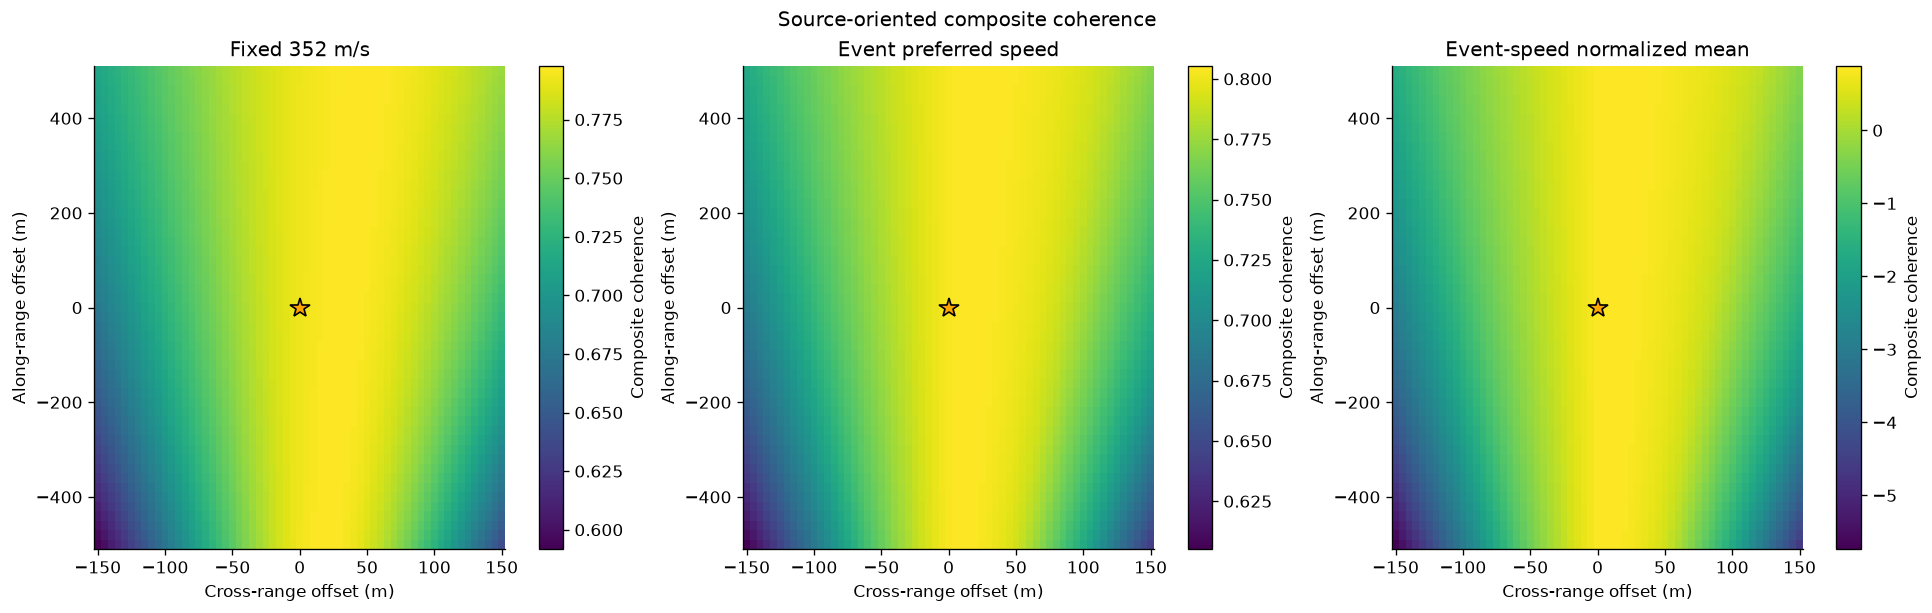

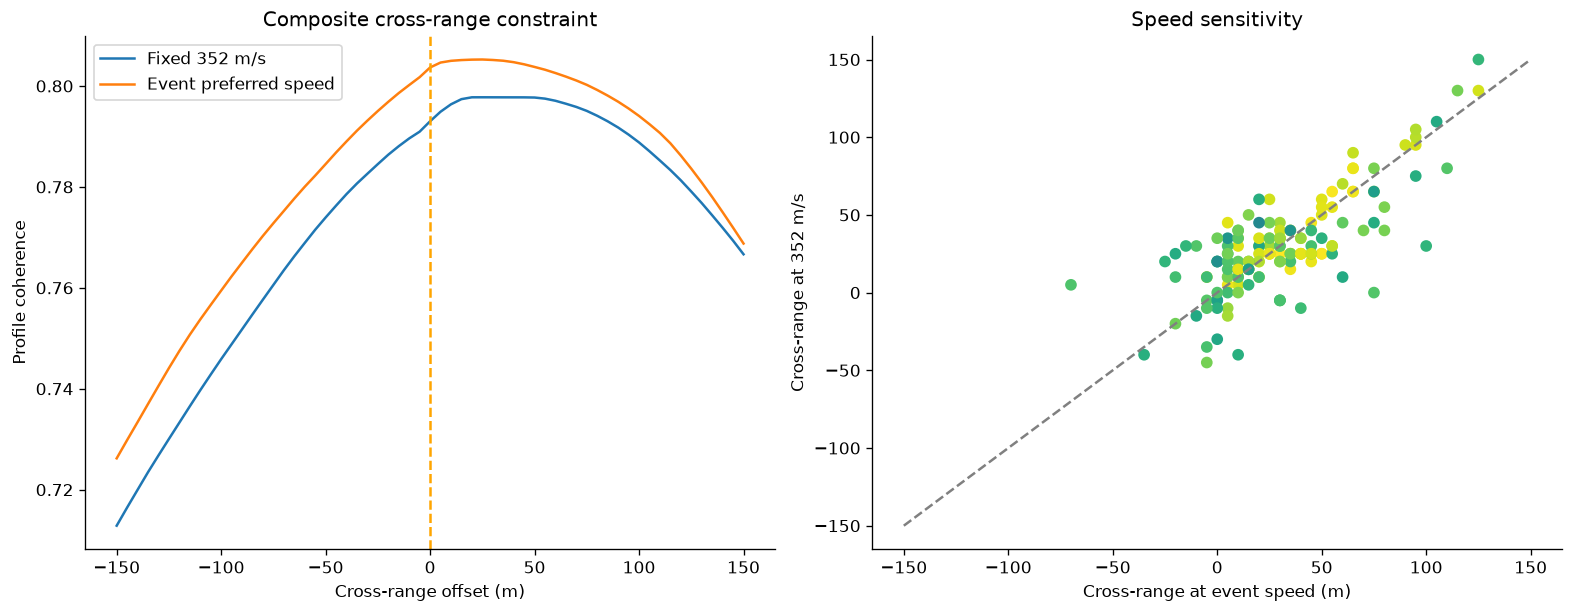

In [7]:
def plot_profile_event(event_number):
    fixed = fixed_results.loc[fixed_results["event_number"] == event_number].iloc[0]
    cached = event_cache[event_number]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
    for ax, surface, title in [
        (axes[0], cached["profile_surface_fixed_speed"], f"Fixed {LOCAL_GRID_SPEED_MPS:.0f} m s$^{{-1}}$"),
        (axes[1], cached["profile_surface_event_speed"], f"Event speed {fixed.fixed_source_speed_mps:.1f} m s$^{{-1}}$"),
    ]:
        mesh = ax.pcolormesh(cross_grid_m, along_grid_m, surface, shading="auto", cmap="viridis")
        ax.plot(0, 0, "*", color="orange", mec="black", ms=12, label="SLC-40")
        ax.set(xlabel="Cross-range offset (m)", ylabel="Along-range offset (m)", title=title)
        ax.legend(fontsize=7)
        fig.colorbar(mesh, ax=ax, label="Coherence")
    axes[2].plot(cross_grid_m, cached["profile_cross_fixed_speed"], label=f"Fixed {LOCAL_GRID_SPEED_MPS:.0f} m/s")
    axes[2].plot(cross_grid_m, cached["profile_cross_event_speed"], label="Event preferred speed")
    axes[2].set(xlabel="Cross-range offset (m)", ylabel="Profile coherence", title="Maximized over range")
    axes[2].legend(fontsize=8)
    axes[2].grid(alpha=0.2)
    fig.suptitle(f"Event {event_number:03d}: circular-wavefront range profiling")
    fig.savefig(FIGURE_DIR / f"event_{event_number:03d}_range_profile.pdf", bbox_inches="tight")
    plt.close(fig)


if MAKE_PROFILE_EVENT_FIGURES and not profile_results.empty:
    selected_profile_events = set(PROFILE_FIGURE_EVENT_NUMBERS)
    selected_profile_events.update(
        profile_results.loc[
            profile_results["solution_quality_class"].isin(PROFILE_FIGURE_QUALITY_CLASSES),
            "event_number",
        ].astype(int)
    )
    for event_number in sorted(selected_profile_events):
        if event_number in event_cache:
            plot_profile_event(int(event_number))
    print(f"Range-profile event figures: {len(selected_profile_events)} selected events in {FIGURE_DIR}")

if profile_event_speed_surfaces:
    stack_fixed_speed = np.stack(profile_fixed_speed_surfaces)
    stack_event = np.stack(profile_event_speed_surfaces)
    composite_fixed_speed = np.nanmean(stack_fixed_speed, axis=0)
    composite_event = np.nanmean(stack_event, axis=0)
    normalized_event = []
    for surface in stack_event:
        baseline = np.nanmedian(surface)
        scale = np.nanmax(surface) - baseline
        normalized_event.append((surface - baseline) / scale if scale > 0 else np.zeros_like(surface))
    composite_normalized = np.nanmean(np.stack(normalized_event), axis=0)
    np.savez_compressed(
        COMPOSITE_DIR / "range_profile_composites.npz",
        along_range_m=along_grid_m, cross_range_m=cross_grid_m,
        fixed_speed_mean=composite_fixed_speed, event_speed_mean=composite_event,
        event_speed_normalized_mean=composite_normalized,
    )
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    for ax, surface, title in zip(
        axes,
        (composite_fixed_speed, composite_event, composite_normalized),
        (f"Fixed {LOCAL_GRID_SPEED_MPS:.0f} m/s", "Event preferred speed", "Event-speed normalized mean"),
    ):
        mesh = ax.pcolormesh(cross_grid_m, along_grid_m, surface, shading="auto", cmap="viridis")
        ax.plot(0, 0, "*", color="orange", mec="black", ms=12)
        ax.set(xlabel="Cross-range offset (m)", ylabel="Along-range offset (m)", title=title)
        fig.colorbar(mesh, ax=ax, label="Composite coherence")
    fig.suptitle("Source-oriented composite coherence")
    fig.savefig(COMPOSITE_DIR / "range_profile_composite_maps.pdf", bbox_inches="tight")
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
    composite_cross_fixed_speed = np.nanmax(composite_fixed_speed, axis=0)
    composite_cross_event = np.nanmax(composite_event, axis=0)
    axes[0].plot(cross_grid_m, composite_cross_fixed_speed, label=f"Fixed {LOCAL_GRID_SPEED_MPS:.0f} m/s")
    axes[0].plot(cross_grid_m, composite_cross_event, label="Event preferred speed")
    axes[0].axvline(0, color="orange", ls="--")
    axes[0].set(xlabel="Cross-range offset (m)", ylabel="Profile coherence", title="Composite cross-range constraint")
    axes[0].legend()
    axes[1].scatter(
        profile_results["event_speed_best_cross_range_m"],
        profile_results["fixed_speed_best_cross_range_m"],
        c=fixed_results["fixed_source_coherence_score"], cmap="viridis", vmin=0, vmax=1,
    )
    lim = CROSS_RANGE_HALF_WIDTH_M
    axes[1].plot([-lim, lim], [-lim, lim], "--", color="0.5")
    axes[1].set(xlabel="Cross-range at event speed (m)", ylabel=f"Cross-range at {LOCAL_GRID_SPEED_MPS:.0f} m/s", title="Speed sensitivity")
    fig.savefig(COMPOSITE_DIR / "cross_range_profile_summary.pdf", bbox_inches="tight")
    plt.show()


## Event figures and the principal explosion

Each figure combines the fixed-source speed curve, fixed-speed local source map,
and waveforms aligned under the preferred circular model. Event 13 receives the
same broader scoring window inherited from Notebook 080.


In [8]:
def plot_event(event_number):
    fixed = fixed_results.loc[fixed_results["event_number"] == event_number].iloc[0]
    cached = event_cache[event_number]
    has_local = "best_local_source" in cached
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

    axes[0].plot(speed_grid, cached["speed_surface"][:, 0], color="black")
    axes[0].axvline(fixed.fixed_source_speed_mps, color="tab:red", ls="--", label="Best exact-distance speed")
    axes[0].axvline(fixed.planar_speed_mps, color="tab:blue", ls=":", label="Planar speed")
    axes[0].axvline(LOCAL_GRID_SPEED_MPS, color="orange", ls="--", label="Local-grid fixed speed")
    axes[0].set(xlabel="Acoustic speed (m s$^{-1}$)", ylabel="Coherence score", title="Fixed SLC-40 source")
    axes[0].legend(fontsize=7)

    if has_local:
        surface = cached["fine_score"]
        east_offset = cached["fine_east"] - slc40_xyz[0]
        north_offset = cached["fine_north"] - slc40_xyz[1]
        mesh = axes[1].pcolormesh(east_offset, north_offset, surface, shading="auto", cmap="viridis")
        source = cached["best_local_source"]
        axes[1].plot(0, 0, marker="*", ms=12, color="orange", mec="black", label="SLC-40")
        axes[1].plot(source[0]-slc40_xyz[0], source[1]-slc40_xyz[1], marker="x", ms=9, color="white", mew=2, label="Best")
        axes[1].set_aspect("equal")
        axes[1].set(xlabel="East offset (m)", ylabel="North offset (m)", title=f"Local source, {LOCAL_GRID_SPEED_MPS:.0f} m s$^{{-1}}$")
        axes[1].legend(fontsize=7)
        fig.colorbar(mesh, ax=axes[1], label="Coherence")
        alignment_source = source
        alignment_speed = LOCAL_GRID_SPEED_MPS
    else:
        axes[1].axis("off")
        alignment_source = slc40_xyz
        alignment_speed = fixed.fixed_source_speed_mps

    times, aligned = aligned_waveforms(
        cached["stream"], cached["reference_epoch_s"],
        delays_for_source(alignment_source, alignment_speed), cached["score_window"],
    )
    for i, channel in enumerate(CHANNELS):
        values = aligned[i] - np.nanmedian(aligned[i])
        scale = np.nanmax(np.abs(values))
        axes[2].plot(times, values / scale + (2-i)*2.2, lw=0.9, label=channel)
    stack = np.nanmedian(aligned - np.nanmedian(aligned, axis=1, keepdims=True), axis=0)
    stack_scale = np.nanmax(np.abs(stack))
    axes[2].plot(times, stack / stack_scale - 2.2, color="black", lw=1.2, label="Median stack")
    axes[2].set(xlabel="Time relative to event reference (s)", ylabel="Normalized and offset", title="Best circular alignment")
    axes[2].legend(fontsize=7)

    fig.suptitle(f"Event {event_number:03d}: circular-wavefront analysis")
    fig.savefig(FIGURE_DIR / f"event_{event_number:03d}_circular_analysis.pdf", bbox_inches="tight")
    plt.close(fig)


if MAKE_EVENT_FIGURES:
    for event_number in fixed_results["event_number"]:
        plot_event(int(event_number))
    print("Event figures:", FIGURE_DIR)

principal = circular_results.loc[circular_results["event_number"] == PRINCIPAL_EXPLOSION_EVENT_NUMBER]
if principal.empty:
    raise ValueError("Principal explosion is missing from circular analysis")
principal.to_csv(OUTPUT_ROOT / "principal_explosion_circular_result.csv", index=False)
display(principal.T)


,12
event_number,13
reference_time_epoch_s,1472735239.427134
reference_time_utc,2016-09-01 13:07:19.427133560+00:00
passes_core_filter,False
solution_quality_class,A_high_quality
...,...
event_speed_along_width_drop_0p02_m,1000.0
event_speed_along_lower_drop_0p02_m,-500.0
event_speed_along_upper_drop_0p02_m,500.0
event_speed_along_open_low_drop_0p02,True


## Composite source map and catalogue comparisons

The composite averages the broad fixed-speed source surfaces. It shows whether
coherence from many events concentrates near SLC-40 or forms an extended ridge.
Individual source offsets are also plotted through time, but their physical
interpretation must respect the surface widths and fixed-speed assumption.


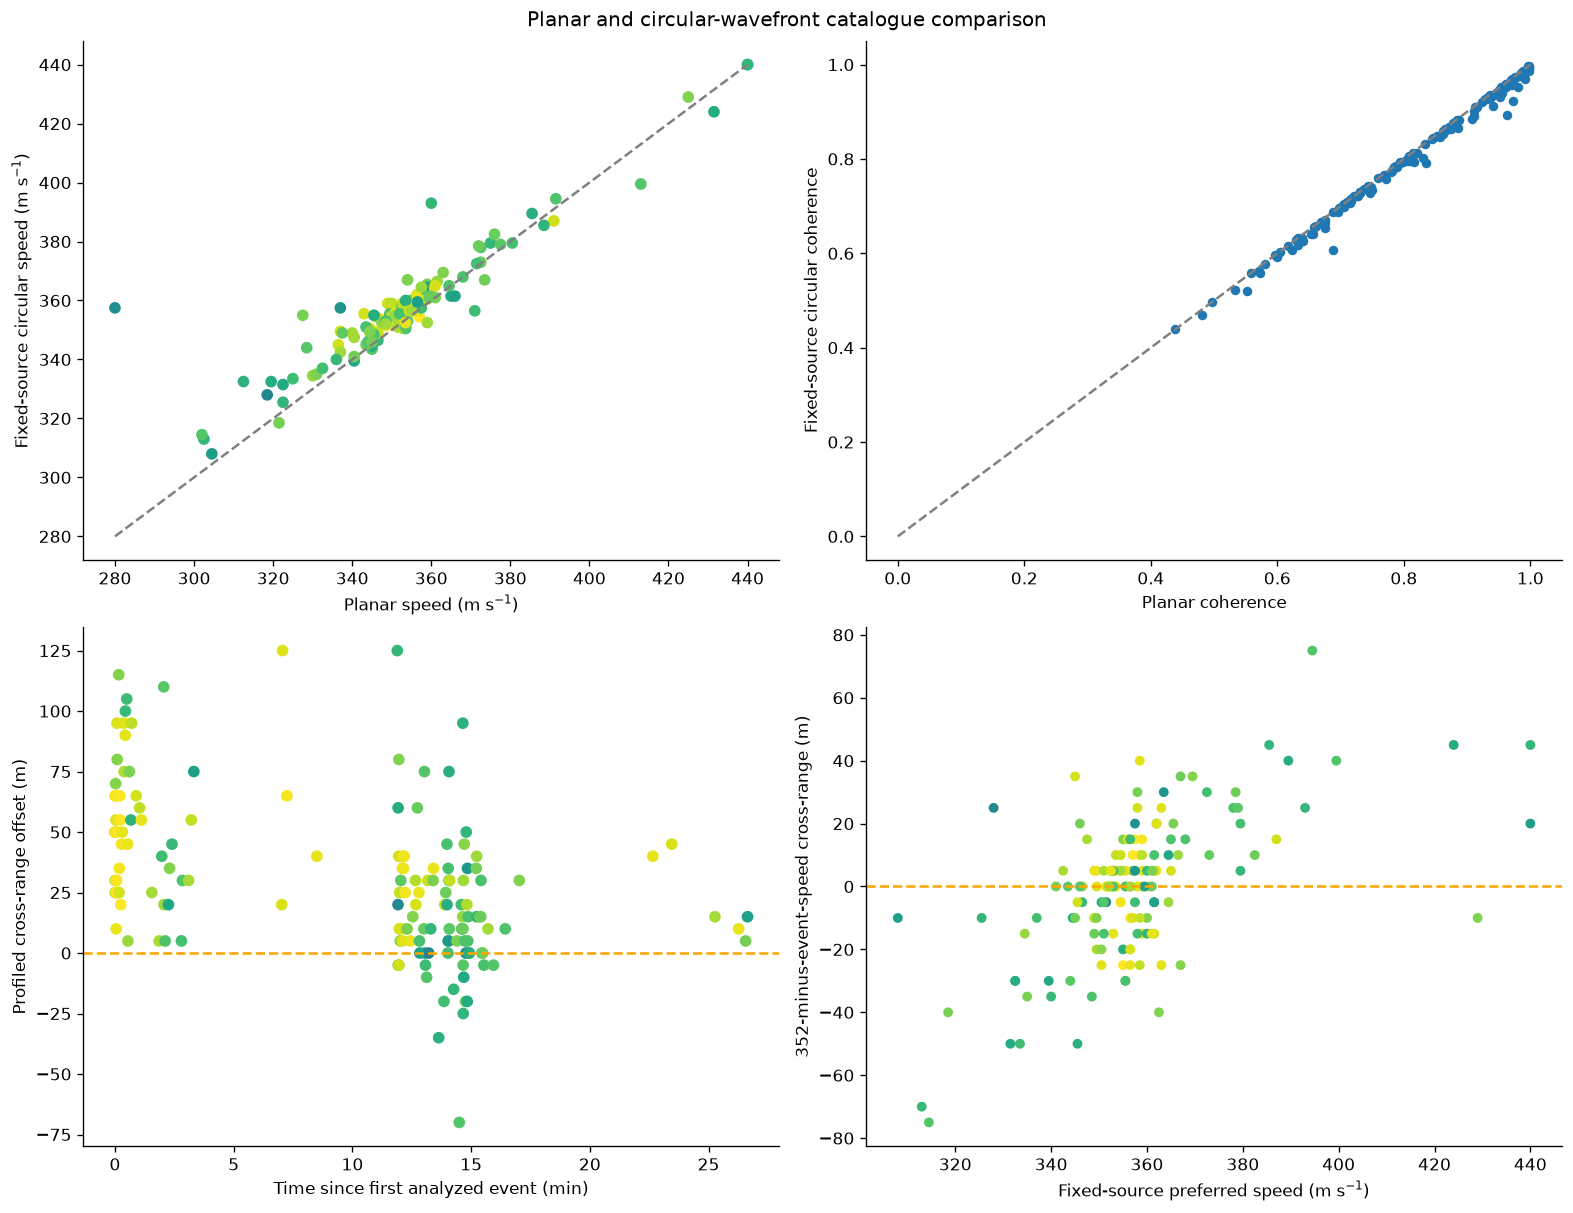

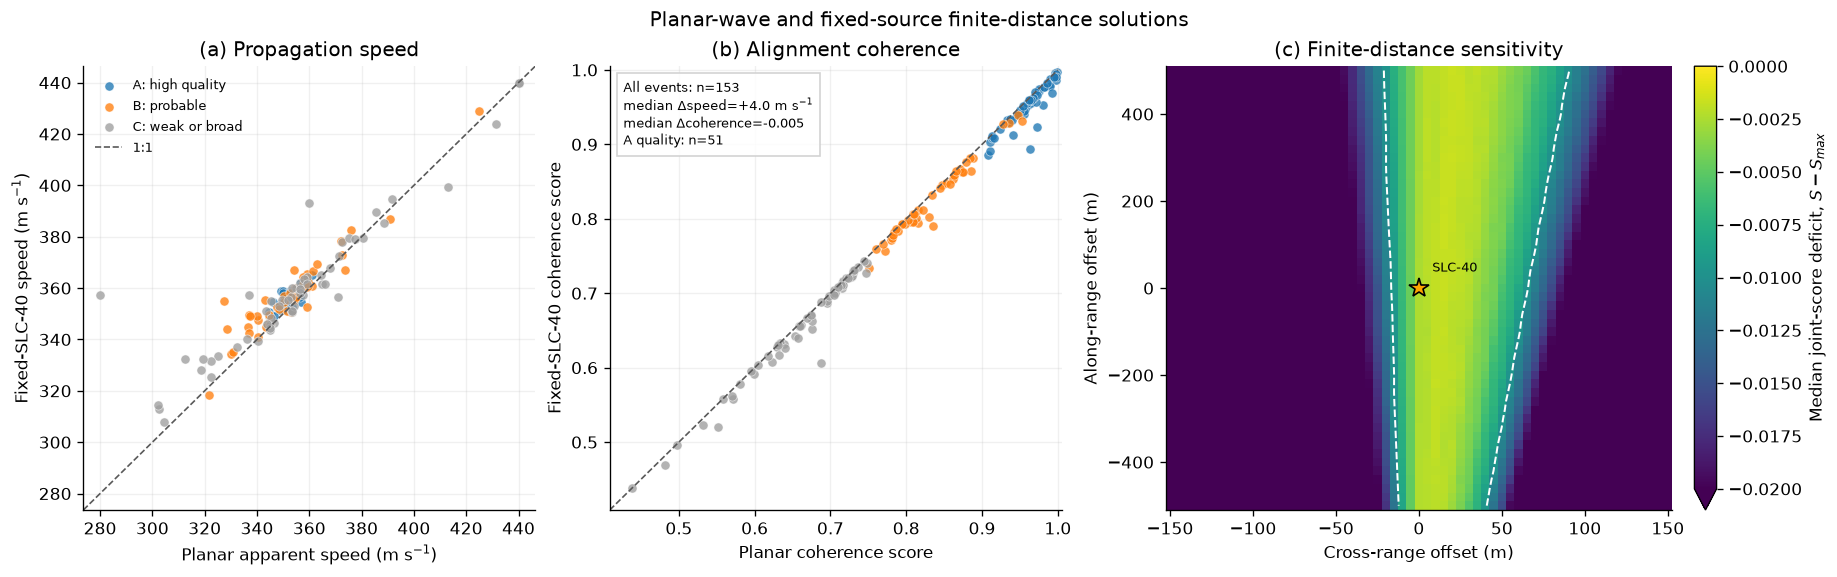

Supplementary comparison: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/090_analyze_finite_distance_propagation/supplement_planar_vs_fixed_source_and_range_sensitivity.pdf


In [9]:
if coarse_composite_surfaces:
    stack = np.stack(coarse_composite_surfaces)
    normalized = []
    for surface in stack:
        baseline = np.nanmedian(surface)
        scale = np.nanmax(surface) - baseline
        normalized.append((surface - baseline) / scale if scale > 0 else np.zeros_like(surface))
    composites = {
        "mean": np.nanmean(stack, axis=0),
        "median": np.nanmedian(stack, axis=0),
        "normalized_mean": np.nanmean(np.stack(normalized), axis=0),
    }
    np.savez_compressed(COMPOSITE_DIR / "local_source_composites.npz",
                        east_offset_m=coarse_east_offsets, north_offset_m=coarse_north_offsets,
                        **composites)
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    for ax, (name, surface) in zip(axes, composites.items()):
        mesh = ax.pcolormesh(coarse_east_offsets, coarse_north_offsets, surface, shading="auto", cmap="viridis")
        ax.plot(0, 0, "*", color="orange", mec="black", ms=13)
        ax.set_aspect("equal")
        ax.set(xlabel="East offset from SLC-40 (m)", ylabel="North offset (m)", title=name.replace("_", " ").title())
        fig.colorbar(mesh, ax=ax, label="Composite coherence")
    fig.suptitle(f"Composite local-source coherence at {LOCAL_GRID_SPEED_MPS:.0f} m s$^{{-1}}$")
    fig.savefig(COMPOSITE_DIR / "local_source_composite_maps.pdf", bbox_inches="tight")
    plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
axes[0,0].scatter(fixed_results["planar_speed_mps"], fixed_results["fixed_source_speed_mps"],
                  c=fixed_results["fixed_source_coherence_score"], cmap="viridis", vmin=0, vmax=1)
lo = min(fixed_results["planar_speed_mps"].min(), fixed_results["fixed_source_speed_mps"].min())
hi = max(fixed_results["planar_speed_mps"].max(), fixed_results["fixed_source_speed_mps"].max())
axes[0,0].plot([lo, hi], [lo, hi], "--", color="0.5")
axes[0,0].set(xlabel="Planar speed (m s$^{-1}$)", ylabel="Fixed-source circular speed (m s$^{-1}$)")

axes[0,1].scatter(fixed_results["planar_coherence_score"], fixed_results["fixed_source_coherence_score"], s=22)
axes[0,1].plot([0,1], [0,1], "--", color="0.5")
axes[0,1].set(xlabel="Planar coherence", ylabel="Fixed-source circular coherence")

if not profile_results.empty:
    merged = circular_results.sort_values("reference_time_epoch_s")
    elapsed_min = (merged["reference_time_epoch_s"] - merged["reference_time_epoch_s"].min()) / 60.0
    axes[1,0].scatter(elapsed_min, merged["event_speed_best_cross_range_m"], c=merged["event_speed_maximum_coherence"], cmap="viridis", vmin=0, vmax=1)
    axes[1,0].axhline(0, color="orange", ls="--")
    axes[1,0].set(xlabel="Time since first analyzed event (min)", ylabel="Profiled cross-range offset (m)")
    axes[1,1].scatter(merged["fixed_source_preferred_speed_mps"], merged["cross_range_speed_sensitivity_m"],
                      c=merged["event_speed_maximum_coherence"], cmap="viridis", vmin=0, vmax=1, s=24)
    axes[1,1].axhline(0, color="orange", ls="--")
    axes[1,1].set(xlabel="Fixed-source preferred speed (m s$^{-1}$)", ylabel=f"{LOCAL_GRID_SPEED_MPS:.0f}-minus-event-speed cross-range (m)")

fig.suptitle("Planar and circular-wavefront catalogue comparison")
fig.savefig(OUTPUT_ROOT / "circular_planar_catalogue_summary.pdf", bbox_inches="tight")
plt.show()


# Publication-ready supplementary comparison. Quality classes are inherited
# from Notebook 080; continuous results remain visible.

quality_style = {
    "A_high_quality": ("tab:blue", "A: high quality"),
    "B_probable": ("tab:orange", "B: probable"),
    "C_weak_or_broad": ("0.62", "C: weak or broad"),
}

if not profile_event_speed_surfaces:
    raise RuntimeError(
        "Run the range-profile analysis before creating the supplementary figure"
    )

# Convert every event surface to coherence relative to its own maximum.
# The median deficit avoids weak events dominating through arbitrary
# normalization and gives the color scale a direct interpretation.
event_delta_surfaces = (
    stack_event
    - np.nanmax(stack_event, axis=(1, 2), keepdims=True)
)
composite_delta = np.nanmedian(event_delta_surfaces, axis=0)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15.2, 4.7),
    constrained_layout=True,
    gridspec_kw={"width_ratios": (1.0, 1.0, 1.12)},
)

# (a) Planar versus fixed-source speed
for quality_class, group in fixed_results.groupby(
    "solution_quality_class",
    sort=False,
):
    color, label = quality_style.get(
        quality_class,
        ("0.4", quality_class.replace("_", " ")),
    )
    axes[0].scatter(
        group["planar_speed_mps"],
        group["fixed_source_speed_mps"],
        s=30,
        alpha=0.78,
        color=color,
        edgecolor="white",
        linewidth=0.35,
        label=label,
    )

    axes[1].scatter(
        group["planar_coherence_score"],
        group["fixed_source_coherence_score"],
        s=30,
        alpha=0.78,
        color=color,
        edgecolor="white",
        linewidth=0.35,
    )

speed_values = fixed_results[
    ["planar_speed_mps", "fixed_source_speed_mps"]
].to_numpy()

speed_lo = float(np.nanmin(speed_values))
speed_hi = float(np.nanmax(speed_values))
speed_pad = max(2.0, 0.04 * (speed_hi - speed_lo))

axes[0].plot(
    [speed_lo - speed_pad, speed_hi + speed_pad],
    [speed_lo - speed_pad, speed_hi + speed_pad],
    ls="--",
    color="0.35",
    lw=1,
    label="1:1",
)

axes[0].set(
    xlim=(speed_lo - speed_pad, speed_hi + speed_pad),
    ylim=(speed_lo - speed_pad, speed_hi + speed_pad),
    xlabel="Planar apparent speed (m s$^{-1}$)",
    ylabel="Fixed-SLC-40 speed (m s$^{-1}$)",
    title="(a) Propagation speed",
)

# (b) Planar versus fixed-source coherence
coherence_values = fixed_results[
    ["planar_coherence_score", "fixed_source_coherence_score"]
].to_numpy()

coh_lo = max(
    0.0,
    float(np.nanmin(coherence_values)) - 0.03,
)

axes[1].plot(
    [coh_lo, 1.0],
    [coh_lo, 1.0],
    ls="--",
    color="0.35",
    lw=1,
)

axes[1].set(
    xlim=(coh_lo, 1.005),
    ylim=(coh_lo, 1.005),
    xlabel="Planar coherence score",
    ylabel="Fixed-SLC-40 coherence score",
    title="(b) Alignment coherence",
)

a_quality = fixed_results[
    "solution_quality_class"
].eq("A_high_quality")

annotation = (
    f"All events: n={len(fixed_results)}\n"
    f"median Δspeed="
    f"{fixed_results['fixed_source_speed_mps'].sub(fixed_results['planar_speed_mps']).median():+.1f} "
    f"m s$^{{-1}}$\n"
    f"median Δcoherence="
    f"{fixed_results['fixed_minus_planar_coherence'].median():+.3f}\n"
    f"A quality: n={int(a_quality.sum())}"
)

axes[1].text(
    0.03,
    0.97,
    annotation,
    transform=axes[1].transAxes,
    va="top",
    ha="left",
    fontsize=8,
    bbox={
        "facecolor": "white",
        "alpha": 0.85,
        "edgecolor": "0.8",
        "pad": 4,
    },
)

# (c) Median range–cross-range coherence deficit
mesh = axes[2].pcolormesh(
    cross_grid_m,
    along_grid_m,
    composite_delta,
    shading="auto",
    cmap="viridis",
    vmin=-0.02,
    vmax=0.0,
)

# Show the region within 0.01 of the maximum.
axes[2].contour(
    cross_grid_m,
    along_grid_m,
    composite_delta,
    levels=[-0.01],
    colors="white",
    linewidths=1.2,
)

axes[2].plot(
    0,
    0,
    marker="*",
    color="orange",
    markeredgecolor="black",
    markersize=12,
)

axes[2].annotate(
    "SLC-40",
    xy=(0, 0),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=8,
    ha="left",
    va="bottom",
)

axes[2].set(
    xlabel="Cross-range offset (m)",
    ylabel="Along-range offset (m)",
    title="(c) Finite-distance sensitivity",
)

colorbar = fig.colorbar(
    mesh,
    ax=axes[2],
    label="Median joint-score deficit, $S-S_{max}$",
    pad=0.02,
    extend="min",
)

for ax in axes[:2]:
    ax.grid(alpha=0.18)

axes[0].legend(
    frameon=False,
    fontsize=8,
    loc="best",
)

fig.suptitle(
    "Planar-wave and fixed-source finite-distance solutions"
)

supplement_base = (
    OUTPUT_ROOT
    / "supplement_planar_vs_fixed_source_and_range_sensitivity"
)

fig.savefig(
    supplement_base.with_suffix(".pdf"),
    bbox_inches="tight",
)

plt.show()

print(
    "Supplementary comparison:",
    supplement_base.with_suffix(".pdf"),
)

## Summary and safeguards

- Notebook 080 is the catalogue and quality authority; Notebook 090 must ingest all
  153 uniquely numbered events in a production run.
- Fixed-SLC-40 speed is a finite-distance sensitivity result. Because source
  direction is imposed, speed may compensate for a small directional mismatch and
  must not replace the planar/Notebook-040 atmospheric-speed estimate.
- Exact Euclidean path differences use reconstructed sensor coordinates and an assumed
  source elevation of 0 m; this is not a fully constrained 3-D source inversion.
- Local and profile grids are diagnostic. Open along-range profiles or edge maxima
  demonstrate poor range constraint rather than a source location.
- Expected curvature across this ~30 m array at ~1.42 km range is about 1 ms or
  less, so large planar–finite-distance differences warrant scrutiny.
- Event 13 is retained and uses the broader scoring window inherited from Notebook 080.

The matched-direction delay audit isolates geometric curvature from differences
in fitted source direction. Projected grid north and geographic north are
reported separately. Profile maxima and score-drop spans remain conditional
on the fixed speed, nominal reconstructed coordinates and assumed source
elevation. A ridge extending to the grid edge is not a bounded source range.


In [10]:
summary = {
    "notebook": "090_analyze_finite_distance_propagation.ipynb",
    "input_files": {"planar_results": str(PLANAR_RESULTS_FILE), "geometry": str(GEOMETRY_FILE), "analysis_configuration": str(ANALYSIS_CONFIG_FILE)},
    "source_coordinate_method": source_coordinate_method,
    "source_elevation_m": SOURCE_ELEVATION_M,
    "coordinate_crs": "EPSG:32617",
    "direction_reference": "Array centroid, projected grid north; configured reference is seismometer/geographic north",
    "scoring_coverage": "All trials must retain every sample of the inherited score window",
    "profile_interval_scope": "Score-drop widths on a fixed-speed grid; not confidence intervals or joint source/speed bounds",
    "principal_row_scope": "Representative catalogue entry 13, not the entire physical explosion complex",
    "speed_grid_mps": [SPEED_MIN_MPS, SPEED_MAX_MPS, SPEED_STEP_MPS],
    "range_grid_m": [ALONG_RANGE_HALF_WIDTH_M, ALONG_RANGE_STEP_M, CROSS_RANGE_HALF_WIDTH_M, CROSS_RANGE_STEP_M],
    "events_analyzed": int(len(fixed_results)),
    "median_planar_speed_mps": float(fixed_results["planar_speed_mps"].median()),
    "median_fixed_source_speed_mps": float(fixed_results["fixed_source_speed_mps"].median()),
    "median_fixed_minus_planar_speed_mps": float((fixed_results["fixed_source_speed_mps"] - fixed_results["planar_speed_mps"]).median()),
    "median_fixed_minus_planar_coherence": float(fixed_results["fixed_minus_planar_coherence"].median()),
    "quality_class_counts": fixed_results["solution_quality_class"].value_counts().to_dict(),
    "slc40_east_m": float(slc40_xyz[0]),
    "slc40_north_m": float(slc40_xyz[1]),
    "slc40_back_azimuth_deg": slc40_back_azimuth_deg,
    "slc40_range_m": slc40_range_m,
    "local_grid_speed_mps": LOCAL_GRID_SPEED_MPS,
    "geometry_model": f"Exact Euclidean source-to-sensor delays; sensor elevations used when available; source elevation fixed at {SOURCE_ELEVATION_M:g} m",
    "interpretation": "Finite-distance model-sensitivity test; fixed-source speed does not supersede the planar/Notebook-040 propagation estimate.",
    "identifiability_warning": "Source east, source north, and speed are not jointly identifiable from three sensors using relative delays alone.",
}

a_quality_results = fixed_results.loc[fixed_results["solution_quality_class"] == "A_high_quality"]
if not a_quality_results.empty:
    summary.update({
        "a_quality_events": int(len(a_quality_results)),
        "a_quality_median_planar_speed_mps": float(a_quality_results["planar_speed_mps"].median()),
        "a_quality_median_fixed_source_speed_mps": float(a_quality_results["fixed_source_speed_mps"].median()),
        "a_quality_median_fixed_minus_planar_speed_mps": float((
            a_quality_results["fixed_source_speed_mps"] - a_quality_results["planar_speed_mps"]
        ).median()),
        "a_quality_median_fixed_minus_planar_coherence": float(
            a_quality_results["fixed_minus_planar_coherence"].median()
        ),
    })
if not local_results.empty:
    summary.update({
        "median_local_cross_range_offset_m": float(local_results["cross_range_offset_m"].median()),
        "median_local_along_range_offset_m": float(local_results["along_range_offset_m"].median()),
        "local_coarse_edge_events": int(local_results["coarse_best_on_edge"].sum()),
        "local_fine_edge_events": int(local_results["fine_best_on_edge"].sum()),
    })
if not profile_results.empty:
    summary.update({
        "median_profile_cross_range_event_speed_m": float(profile_results["event_speed_best_cross_range_m"].median()),
        "median_profile_cross_range_fixed_speed_m": float(profile_results["fixed_speed_best_cross_range_m"].median()),
        "median_cross_range_speed_sensitivity_m": float(profile_results["cross_range_speed_sensitivity_m"].median()),
        "event_speed_along_range_edge_events": int(profile_results["event_speed_best_on_along_edge"].sum()),
        "event_speed_cross_range_edge_events": int(profile_results["event_speed_best_on_cross_edge"].sum()),
        "event_speed_along_profile_open_events_drop_0p01": int((
            profile_results["event_speed_along_open_low_drop_0p01"]
            | profile_results["event_speed_along_open_high_drop_0p01"]
        ).sum()),
        "event_speed_cross_profile_open_events_drop_0p01": int((
            profile_results["event_speed_cross_open_low_drop_0p01"]
            | profile_results["event_speed_cross_open_high_drop_0p01"]
        ).sum()),
    })
(OUTPUT_ROOT / "circular_analysis_summary.json").write_text(json.dumps(summary, indent=2))
display(pd.Series(summary, name="value").to_frame())
print("Primary comparison:", OUTPUT_ROOT / "circular_planar_comparison.csv")


,value
notebook,090_analyze_finite_distance_propagation.ipynb
input_files,{'planar_results': '/Users/thompsong/Developer...
source_coordinate_method,canonical SLC-40 latitude/longitude
source_elevation_m,0.0
coordinate_crs,EPSG:32617
direction_reference,"Array centroid, projected grid north; configur..."
scoring_coverage,All trials must retain every sample of the inh...
profile_interval_scope,Score-drop widths on a fixed-speed grid; not c...
principal_row_scope,"Representative catalogue entry 13, not the ent..."
speed_grid_mps,"[280.0, 440.0, 0.5]"


Primary comparison: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/090_analyze_finite_distance_propagation/circular_planar_comparison.csv
